## Fine-tune ResNet-18 on `data/DATASET` (native resolution)

Ignores the ground-resolution resize from `resize.ipynb` entirely — this trains directly on the original leaf `.tif` crops. Each leaf-stage sample has 5 single-band images (bands 1-5); ResNet-18's first conv is swapped from 3 to 5 input channels, keeping the pretrained RGB weights for the first 3 and copying them into the extra 2 rather than reinitializing randomly.

**Target:** 4 continuous traits per leaf-stage — moisture (FMC, dry-mass basis), chlorophyll (SPAD), nitrogen, and weight — trained as one multi-output regression head.

**Split:** grouped by leaf, not by row, and three-way. All 5 dehydration stages of a given leaf go entirely into train, val, or test — never split across them. Val is used during training to monitor progress; test is set aside untouched and only scored once at the end, on leaves the model never saw in any form during training.

In [14]:
import re
from pathlib import Path

import numpy as np
import scipy.io as sio
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score, mean_absolute_error
from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights

torch.manual_seed(0)
np.random.seed(0)

DATA_DIR = Path("../data") if Path("../data/DATASET").exists() else Path("data")
ROOT = DATA_DIR / "DATASET"
SPECIES = ["Avocado", "Olive", "Vineyard"]
TRAITS = ["fmc", "chlorophyll", "nitrogen", "weight"]
IMG_SIZE = 112

### Load labels

Each `.mat` file is a (leaf x stage) matrix — row index is the leaf number from the filename (`leaf000`, `leaf001`, ...), column index is the dehydration stage (`d0`-`d4`). Verified directly against the paper's own sample script: row = leaf, column = stage, 0-indexed.

In [15]:
def load_labels(species: str) -> dict:
    s = species.lower()
    fmc = sio.loadmat(ROOT / species / f"FMC_{s}.mat")[f"FMC_d_{s}"]
    chl = sio.loadmat(ROOT / species / f"Chlorophyll_{s}.mat")[f"chlorophyll_{s}"]
    nit = sio.loadmat(ROOT / species / f"Nitrogen_{s}.mat")[f"nitrogen_{s}"]
    weight_file = ROOT / species / f"Weight_{species}.mat"  # avocado's filename capitalizes species
    if not weight_file.exists():
        weight_file = ROOT / species / f"Weight_{s}.mat"
    wgt = sio.loadmat(weight_file)[f"weight_{s}"]
    return {"fmc": fmc, "chlorophyll": chl, "nitrogen": nit, "weight": wgt}


labels_by_species = {sp: load_labels(sp) for sp in SPECIES}
for sp, d in labels_by_species.items():
    print(sp, {k: v.shape for k, v in d.items()})

Avocado {'fmc': (104, 5), 'chlorophyll': (104, 5), 'nitrogen': (104, 5), 'weight': (104, 5)}
Olive {'fmc': (111, 5), 'chlorophyll': (111, 5), 'nitrogen': (111, 5), 'weight': (111, 5)}
Vineyard {'fmc': (104, 5), 'chlorophyll': (104, 5), 'nitrogen': (104, 5), 'weight': (104, 5)}


### Build the sample index

One sample = one (species, leaf, stage) with all 5 band files present.

In [16]:
PATTERN = re.compile(r"leaf(\d+)d(\d+)_(\d+)\.tif")

samples = []  # each: dict(species, leaf, stage, band_paths)
for sp in SPECIES:
    img_dir = ROOT / sp / "Multispectral Images"
    by_key = {}
    for p in img_dir.glob("*.tif"):
        m = PATTERN.match(p.name)
        if not m:
            continue
        leaf, stage, band = int(m.group(1)), int(m.group(2)), int(m.group(3))
        by_key.setdefault((leaf, stage), {})[band] = p

    for (leaf, stage), bands in by_key.items():
        if set(bands) != {1, 2, 3, 4, 5}:
            continue  # incomplete band set -- skip defensively
        labels = labels_by_species[sp]
        if leaf >= labels["fmc"].shape[0]:
            continue  # no label row for this leaf -- skip defensively
        target = np.array([labels[t][leaf, stage] for t in TRAITS], dtype=np.float32)
        samples.append({
            "species": sp,
            "leaf": leaf,
            "stage": stage,
            "band_paths": [bands[b] for b in range(1, 6)],
            "target": target,
        })

print(f"{len(samples)} labeled leaf-stage samples across {len(SPECIES)} species")

1595 labeled leaf-stage samples across 3 species


### Leaf-grouped train/val/test split

Test is carved off first, from the full pool. Val is then carved off the remainder. Both cuts are grouped by leaf, so a leaf's 5 stages never end up split across two of the three sets.

In [17]:
TEST_SIZE = 0.15  # fraction of ALL leaves
VAL_SIZE = 0.15   # fraction of ALL leaves (taken from the remainder after test is removed)

groups = np.array([f"{s['species']}_{s['leaf']}" for s in samples])
all_idx = np.arange(len(samples))

test_splitter = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=0)
trainval_idx, test_idx = next(test_splitter.split(all_idx, groups=groups))

val_fraction_of_remainder = VAL_SIZE / (1 - TEST_SIZE)
val_splitter = GroupShuffleSplit(n_splits=1, test_size=val_fraction_of_remainder, random_state=0)
train_sub, val_sub = next(val_splitter.split(trainval_idx, groups=groups[trainval_idx]))
train_idx = trainval_idx[train_sub]
val_idx = trainval_idx[val_sub]

train_groups = set(groups[train_idx])
val_groups = set(groups[val_idx])
test_groups = set(groups[test_idx])
assert train_groups.isdisjoint(val_groups), "a leaf leaked between train and val"
assert train_groups.isdisjoint(test_groups), "a leaf leaked between train and test"
assert val_groups.isdisjoint(test_groups), "a leaf leaked between val and test"

print(f"train: {len(train_idx)} samples, {len(train_groups)} leaves")
print(f"val:   {len(val_idx)} samples, {len(val_groups)} leaves")
print(f"test:  {len(test_idx)} samples, {len(test_groups)} leaves")
print("no leaf appears in more than one split: confirmed")

train: 1115 samples, 223 leaves
val:   240 samples, 48 leaves
test:  240 samples, 48 leaves
no leaf appears in more than one split: confirmed


### Load and cache images in memory

The dataset is small enough (~1,600 samples x 5 bands) to decode and resize once up front rather than re-reading from disk every epoch.

In [18]:
def load_sample_image(band_paths: list[Path]) -> np.ndarray:
    bands = []
    for p in band_paths:
        im = Image.open(p).resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        bands.append(np.array(im, dtype=np.float32))
    return np.stack(bands, axis=0) / 65535.0  # (5, H, W), scaled to roughly [0, 1]


def build_arrays(idxs: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    X = np.zeros((len(idxs), 5, IMG_SIZE, IMG_SIZE), dtype=np.float32)
    y = np.zeros((len(idxs), len(TRAITS)), dtype=np.float32)
    for i, idx in enumerate(idxs):
        s = samples[idx]
        X[i] = load_sample_image(s["band_paths"])
        y[i] = s["target"]
    return X, y


X_train, y_train = build_arrays(train_idx)
X_val, y_val = build_arrays(val_idx)
X_test, y_test = build_arrays(test_idx)
print("X_train", X_train.shape, "X_val", X_val.shape, "X_test", X_test.shape)

X_train (1115, 5, 112, 112) X_val (240, 5, 112, 112) X_test (240, 5, 112, 112)


### Standardize targets

The 4 traits live on very different scales (chlorophyll ~tens, weight ~grams, FMC ~percent). Mean/std are computed on the train split only, then applied to both.

In [19]:
y_mean = y_train.mean(axis=0)
y_std = y_train.std(axis=0)

y_train_z = (y_train - y_mean) / y_std
y_val_z = (y_val - y_mean) / y_std
y_test_z = (y_test - y_mean) / y_std  # test never contributes to mean/std -- train-only statistics

for t, m, s in zip(TRAITS, y_mean, y_std):
    print(f"{t:12s} mean={m:9.3f}  std={s:9.3f}")

fmc          mean=   78.503  std=   69.242
chlorophyll  mean=   63.007  std=   34.025
nitrogen     mean=   19.156  std=    6.498
weight       mean=    0.908  std=    0.844


### Model: ResNet-18, 5-channel input, 4-output regression head

In [20]:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

old_conv = model.conv1
new_conv = nn.Conv2d(5, old_conv.out_channels, kernel_size=old_conv.kernel_size,
                      stride=old_conv.stride, padding=old_conv.padding, bias=False)
with torch.no_grad():
    new_conv.weight[:, :3] = old_conv.weight            # keep pretrained RGB filters
    new_conv.weight[:, 3:5] = old_conv.weight[:, :2]     # seed the extra 2 channels from the first 2
model.conv1 = new_conv

model.fc = nn.Linear(model.fc.in_features, len(TRAITS))

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
model.to(device)
print(f"model ready on {device}")

model ready on cpu


### Train, with early stopping

Trains up to `EPOCHS`, but stops once `val_loss` hasn't improved for `PATIENCE` consecutive epochs. The best-epoch weights (lowest `val_loss` seen, not the final epoch's) are restored into `model` after the loop — everything downstream (val/test eval, plots, checkpoint save) uses that restored model.

In [ ]:
BATCH_SIZE = 32
EPOCHS = 30
LR = 1e-4
PATIENCE = 5  # stop after this many epochs with no val_loss improvement

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train_z))
val_ds = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val_z))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

best_val_loss = float("inf")
best_epoch = 0
best_state = None
epochs_without_improvement = 0

history = {"train_loss": [], "val_loss": []}
for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)
    train_loss = running / len(train_ds)

    model.eval()
    running = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            running += loss_fn(pred, yb).item() * xb.size(0)
    val_loss = running / len(val_ds)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    improved = val_loss < best_val_loss
    if improved:
        best_val_loss = val_loss
        best_epoch = epoch
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    flag = " *" if improved else ""
    print(f"epoch {epoch:2d}/{EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}{flag}")

    if epochs_without_improvement >= PATIENCE:
        print(f"no val_loss improvement for {PATIENCE} epochs -- stopping early")
        break

model.load_state_dict(best_state)
print(f"restored weights from epoch {best_epoch} (val_loss={best_val_loss:.4f})")

epoch  1/30  train_loss=0.6112  val_loss=0.4342 *
epoch  2/30  train_loss=0.2714  val_loss=0.2918 *
epoch  3/30  train_loss=0.1722  val_loss=0.3180
epoch  4/30  train_loss=0.1191  val_loss=0.2628 *
epoch  5/30  train_loss=0.0795  val_loss=0.2457 *
epoch  6/30  train_loss=0.0769  val_loss=0.2378 *
epoch  7/30  train_loss=0.0704  val_loss=0.2183 *


### Loss curve

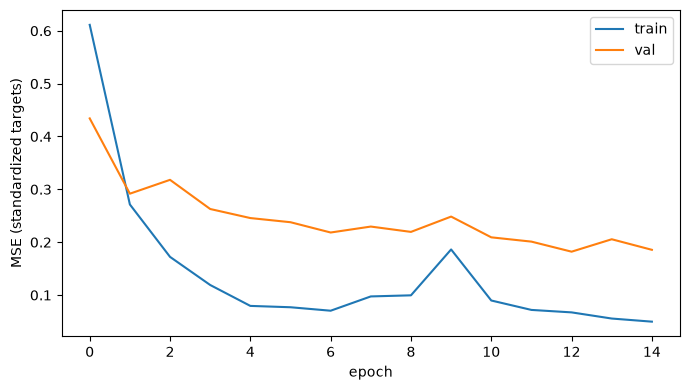

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("MSE (standardized targets)")
plt.legend()
plt.tight_layout()
plt.show()

### Val performance per trait (original units)

In [ ]:
model.eval()
preds_z = []
with torch.no_grad():
    for xb, _ in val_loader:
        preds_z.append(model(xb.to(device)).cpu().numpy())
preds_z = np.concatenate(preds_z, axis=0)
preds = preds_z * y_std + y_mean  # back to original units

print(f"{'trait':12s} {'R2':>8s} {'MAE':>10s}")
for i, t in enumerate(TRAITS):
    r2 = r2_score(y_val[:, i], preds[:, i])
    mae = mean_absolute_error(y_val[:, i], preds[:, i])
    print(f"{t:12s} {r2:8.3f} {mae:10.3f}")

trait              R2        MAE
fmc             0.794     27.931
chlorophyll     0.797      8.093
nitrogen        0.838      2.092
weight          0.773      0.283


### Test performance (held out, never touched during training)

`test_idx` was never used in the training loop, in early-stopping decisions, or anywhere else — this is the first time the model sees these leaves.

In [ ]:
test_ds = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test_z))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

model.eval()
test_preds_z = []
with torch.no_grad():
    for xb, _ in test_loader:
        test_preds_z.append(model(xb.to(device)).cpu().numpy())
test_preds_z = np.concatenate(test_preds_z, axis=0)
test_preds = test_preds_z * y_std + y_mean  # back to original units

print(f"{'trait':12s} {'R2':>8s} {'MAE':>10s}")
for i, t in enumerate(TRAITS):
    r2 = r2_score(y_test[:, i], test_preds[:, i])
    mae = mean_absolute_error(y_test[:, i], test_preds[:, i])
    print(f"{t:12s} {r2:8.3f} {mae:10.3f}")

trait              R2        MAE
fmc             0.806     23.379
chlorophyll     0.761      8.795
nitrogen        0.836      2.082
weight          0.808      0.288


### Test set: predicted vs. actual, per trait

Each point is one held-out leaf-stage sample. The dashed line is perfect prediction (predicted = actual) — the tighter the scatter hugs it, the better.

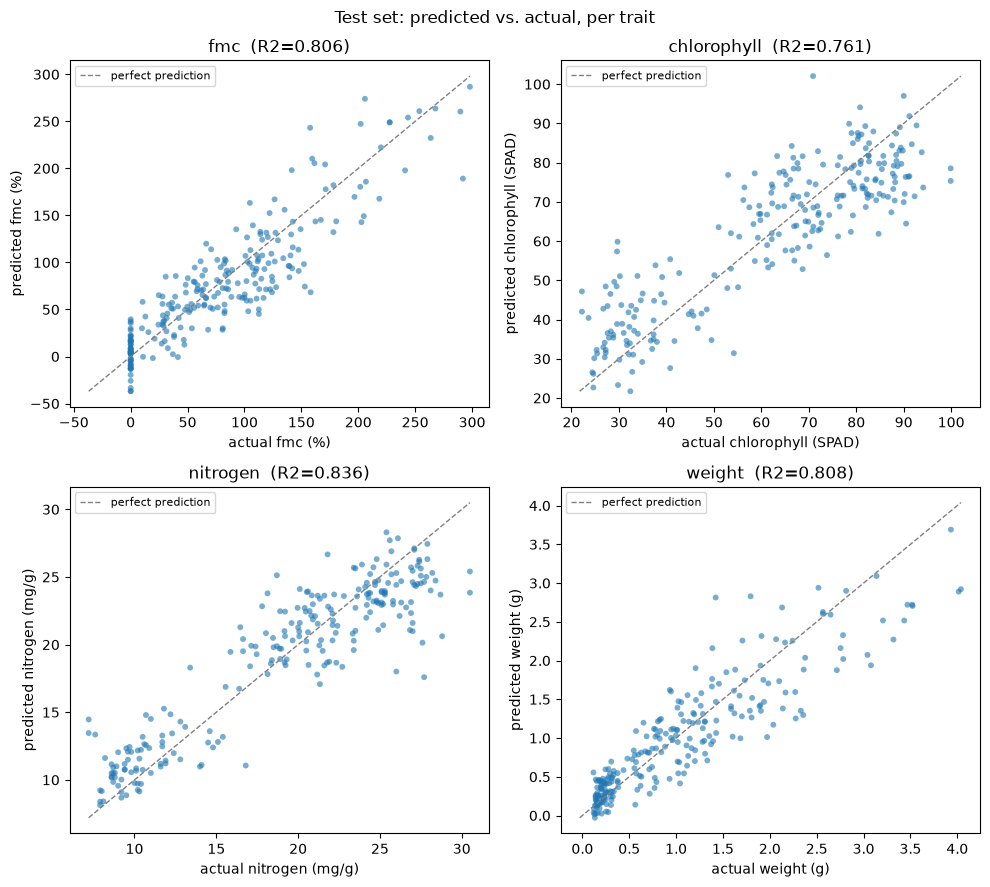

In [ ]:
TRAIT_UNITS = {"fmc": "%", "chlorophyll": "SPAD", "nitrogen": "mg/g", "weight": "g"}

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for i, (t, ax) in enumerate(zip(TRAITS, axes.flat)):
    actual = y_test[:, i]
    predicted = test_preds[:, i]
    r2 = r2_score(actual, predicted)

    lo = min(actual.min(), predicted.min())
    hi = max(actual.max(), predicted.max())
    ax.plot([lo, hi], [lo, hi], "--", color="grey", linewidth=1, label="perfect prediction")
    ax.scatter(actual, predicted, s=18, alpha=0.6, edgecolor="none")

    ax.set_xlabel(f"actual {t} ({TRAIT_UNITS[t]})")
    ax.set_ylabel(f"predicted {t} ({TRAIT_UNITS[t]})")
    ax.set_title(f"{t}  (R2={r2:.3f})")
    ax.legend(fontsize=8)

fig.suptitle("Test set: predicted vs. actual, per trait")
fig.tight_layout()
plt.show()

15 epochs and no hyperparameter tuning — this is a working POC pipeline, not a tuned result. Val (used during training to watch for overfitting) and test (touched exactly once, at the very end) are two separate leaf-disjoint sets, both disjoint from train — treat the test numbers above as the real read on generalization to unseen leaves, and the val numbers as a training-time diagnostic, not a second opinion on the same thing.

In [ ]:
from datetime import datetime

CHECKPOINT_DIR = Path("checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
CHECKPOINT_PATH = CHECKPOINT_DIR / f"resnet18_leaf_traits_{timestamp}.pt"

torch.save({
    "model_state_dict": model.state_dict(),
    "traits": TRAITS,
    "trait_units": TRAIT_UNITS,
    "y_mean": y_mean,
    "y_std": y_std,
    "img_size": IMG_SIZE,
    "in_channels": 5,
}, CHECKPOINT_PATH)

print(f"saved to {CHECKPOINT_PATH.resolve()}  ({CHECKPOINT_PATH.stat().st_size / 1e6:.1f} MB)")

In [ ]:
# checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")

# loaded_model = resnet18(weights=None)
# old_conv = loaded_model.conv1
# loaded_model.conv1 = nn.Conv2d(checkpoint["in_channels"], old_conv.out_channels,
#                                 kernel_size=old_conv.kernel_size, stride=old_conv.stride,
#                                 padding=old_conv.padding, bias=False)
# loaded_model.fc = nn.Linear(loaded_model.fc.in_features, len(checkpoint["traits"]))
# loaded_model.load_state_dict(checkpoint["model_state_dict"])
# loaded_model.eval()

# inference: pred_z = loaded_model(x); pred = pred_z.detach().numpy() * checkpoint["y_std"] + checkpoint["y_mean"]
